# 피처 선택 파이프라인

## 처리 순서
| 단계 | 방법 | 기준 |
|------|------|------|
| STEP 1 | **Welch t-test** | p < 0.01 — 정상/부실 그룹 간 평균 유의 차이 |
| STEP 2 | **LASSO (LassoCV)** | alpha를 CV로 결정, 계수 ≠ 0 피처 |
| STEP 3 | **교집합** | 두 방법 모두 통과한 피처만 유지 |
| STEP 4 | **VIF 반복 제거** | VIF > 10 피처를 최댓값부터 1개씩 자동 제거 |

## 제외 피처
- 메타 컬럼: 사업자등록번호, 회계년도, 회사명, 종업원, M코드, 빅4감사, 통계청 산업분류
- 라벨 파생: 부실라벨_ICR3년_diff/ratio, 빅4감사_diff/ratio
- 비재무 파생: 통계청 산업분류_diff/ratio/diff_industry/ratio_industry

## 입력 파일
`10,11,12번 [Train].parquet` — 이미 분리된 학습 데이터 (2012~2022년)

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

## 정규성 검증

In [2]:
"""
정규성 검증 스크립트
- Shapiro-Wilk (n <= 5000 샘플), Anderson-Darling, D'Agostino-Pearson 3가지 검정 병행
- 식별자 컬럼 제외한 모든 수치형 컬럼 대상
- 결과를 CSV + 시각적 요약으로 저장
"""

import pandas as pd
import numpy as np
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')

# ── 설정 ─────────────────────────────────────────────────────────────────────
DATA_PATH   = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\10,11,12번\train데이터\M19_도매_소매업_train.parquet'
OUTPUT_DIR  = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리'
OUTPUT_CSV  = os.path.join(OUTPUT_DIR, 'normality_test_results.csv')
ALPHA       = 0.05          # 유의수준
SHAPIRO_N   = 5_000         # Shapiro-Wilk은 n이 크면 느리므로 샘플링
SAMPLE_SEED = 42

# 제외할 식별자 컬럼
EXCLUDE_COLS = {
    '사업자등록번호',
    '회계년도',
    '회사명',
    '통계청 한국표준산업분류 코드 11차(대분류)',
    '통계청 한국표준산업분류 11차(중분류)',
    '부실라벨_ICR3년',
    'M코드',
    '회사명_norm',
    '빅4감사',
}

# ── 데이터 로드 ───────────────────────────────────────────────────────────────
print("▶ 데이터 로드 중...")
df = pd.read_parquet(DATA_PATH)
print(f"  Shape: {df.shape}")

# 수치형 컬럼 중 식별자 제외
numeric_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in EXCLUDE_COLS
]
print(f"  정규성 검정 대상 컬럼 수: {len(numeric_cols)}")

# ── 정규성 검정 함수 ──────────────────────────────────────────────────────────
def run_normality_tests(series: pd.Series, col_name: str) -> dict:
    """단일 컬럼에 대해 3가지 정규성 검정 수행"""
    # NaN 제거
    data = series.dropna().values.astype(float)
    n_total = len(series)
    n_valid = len(data)
    n_missing = n_total - n_valid
    missing_pct = round(n_missing / n_total * 100, 2)

    result = {
        'column': col_name,
        'n_total': n_total,
        'n_valid': n_valid,
        'n_missing': n_missing,
        'missing_pct': missing_pct,
        'mean': np.nan,
        'std': np.nan,
        'skewness': np.nan,
        'kurtosis': np.nan,
        # Shapiro-Wilk
        'shapiro_stat': np.nan,
        'shapiro_pvalue': np.nan,
        'shapiro_normal': np.nan,
        'shapiro_note': '',
        # Anderson-Darling
        'anderson_stat': np.nan,
        'anderson_critical_5pct': np.nan,
        'anderson_normal': np.nan,
        # D'Agostino-Pearson (K2)
        'dagostino_stat': np.nan,
        'dagostino_pvalue': np.nan,
        'dagostino_normal': np.nan,
        # 종합 판정
        'majority_normal': np.nan,
        'all_normal': np.nan,
    }

    # 유효 데이터가 너무 적으면 스킵
    if n_valid < 8:
        result['shapiro_note'] = f'유효샘플 부족 ({n_valid}개)'
        return result

    # 기술통계
    result['mean']     = round(float(np.mean(data)), 6)
    result['std']      = round(float(np.std(data, ddof=1)), 6)
    result['skewness'] = round(float(stats.skew(data)), 4)
    result['kurtosis'] = round(float(stats.kurtosis(data)), 4)  # excess kurtosis

    # ── 1. Shapiro-Wilk ──────────────────────────────────────────────────────
    # n > 5000이면 랜덤 서브샘플링 (속도 확보)
    sw_note = ''
    if n_valid > SHAPIRO_N:
        rng = np.random.default_rng(SAMPLE_SEED)
        sw_data = rng.choice(data, size=SHAPIRO_N, replace=False)
        sw_note = f'샘플링({SHAPIRO_N}/{n_valid})'
    else:
        sw_data = data
    try:
        sw_stat, sw_p = stats.shapiro(sw_data)
        result['shapiro_stat']   = round(float(sw_stat), 6)
        result['shapiro_pvalue'] = round(float(sw_p), 6)
        result['shapiro_normal'] = int(sw_p > ALPHA)
        result['shapiro_note']   = sw_note
    except Exception as e:
        result['shapiro_note'] = f'오류: {e}'

    # ── 2. Anderson-Darling ──────────────────────────────────────────────────
    try:
        ad_result = stats.anderson(data, dist='norm')
        # 5% 유의수준 인덱스 (0=15%, 1=10%, 2=5%, 3=2.5%, 4=1%)
        idx_5pct = 2
        ad_stat   = float(ad_result.statistic)
        ad_crit   = float(ad_result.critical_values[idx_5pct])
        result['anderson_stat']         = round(ad_stat, 6)
        result['anderson_critical_5pct']= round(ad_crit, 6)
        result['anderson_normal']       = int(ad_stat < ad_crit)  # 검정통계량 < 임계값이면 정규
    except Exception as e:
        result['anderson_stat'] = f'오류: {e}'

    # ── 3. D'Agostino-Pearson (K2) ───────────────────────────────────────────
    # 최소 20개 필요
    if n_valid >= 20:
        try:
            k2_stat, k2_p = stats.normaltest(data)
            result['dagostino_stat']   = round(float(k2_stat), 6)
            result['dagostino_pvalue'] = round(float(k2_p), 6)
            result['dagostino_normal'] = int(k2_p > ALPHA)
        except Exception as e:
            result['dagostino_stat'] = f'오류: {e}'

    # ── 종합 판정 ────────────────────────────────────────────────────────────
    votes = [
        result['shapiro_normal'],
        result['anderson_normal'],
        result['dagostino_normal'],
    ]
    valid_votes = [v for v in votes if isinstance(v, (int, float)) and not np.isnan(v)]
    if valid_votes:
        sum_votes = sum(valid_votes)
        result['majority_normal'] = int(sum_votes >= 2)   # 다수결 (2/3 이상)
        result['all_normal']      = int(sum_votes == len(valid_votes))  # 전체 합의

    return result


# ── 전체 컬럼 검정 실행 ───────────────────────────────────────────────────────
print("\n▶ 정규성 검정 실행 중...")
results = []
total = len(numeric_cols)

for i, col in enumerate(numeric_cols):
    if (i + 1) % 50 == 0 or (i + 1) == total:
        print(f"  진행: {i+1}/{total} ({(i+1)/total*100:.1f}%)")
    results.append(run_normality_tests(df[col], col))

results_df = pd.DataFrame(results)

# ── 결과 저장 ─────────────────────────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
results_df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f"\n✅ 결과 저장 완료: {OUTPUT_CSV}")

# ── 요약 출력 ─────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("📊 정규성 검정 요약")
print("="*60)

n_cols = len(results_df)
n_majority_normal   = results_df['majority_normal'].sum()
n_majority_nonnorm  = n_cols - n_majority_normal
n_all_normal        = results_df['all_normal'].sum()

print(f"\n총 검정 컬럼 수   : {n_cols}")
print(f"유의수준          : α = {ALPHA}")
print(f"\n[다수결 판정 - 3개 검정 중 2개 이상 정규]")
print(f"  정규분포 O      : {int(n_majority_normal)}개  ({n_majority_normal/n_cols*100:.1f}%)")
print(f"  정규분포 X      : {int(n_majority_nonnorm)}개  ({n_majority_nonnorm/n_cols*100:.1f}%)")
print(f"\n[전체 합의 - 3개 검정 모두 정규]")
print(f"  정규분포 O      : {int(n_all_normal)}개  ({n_all_normal/n_cols*100:.1f}%)")

print("\n[각 검정별 정규 비율]")
for test_col, label in [
    ('shapiro_normal',   'Shapiro-Wilk     '),
    ('anderson_normal',  'Anderson-Darling '),
    ('dagostino_normal', "D'Agostino-Pearson"),
]:
    col_data = results_df[test_col].dropna()
    n_norm = int(col_data.sum())
    print(f"  {label}: {n_norm}/{len(col_data)} ({n_norm/len(col_data)*100:.1f}%)")

# 왜도/첨도 분포 요약
print("\n[왜도(Skewness) 절대값 분포]")
sk = results_df['skewness'].abs().dropna()
print(f"  |skew| < 0.5  (거의 대칭)   : {(sk < 0.5).sum()}개")
print(f"  0.5 ≤ |skew| < 1 (약간 비대칭): {((sk >= 0.5) & (sk < 1)).sum()}개")
print(f"  1 ≤ |skew| < 2  (중간 비대칭) : {((sk >= 1) & (sk < 2)).sum()}개")
print(f"  |skew| ≥ 2    (강한 비대칭)  : {(sk >= 2).sum()}개")

# 비정규 컬럼 상위 목록 (왜도 기준)
print("\n[왜도 절대값 상위 10개 컬럼]")
top_skew = (
    results_df[['column', 'skewness', 'kurtosis', 'majority_normal']]
    .assign(abs_skew=results_df['skewness'].abs())
    .sort_values('abs_skew', ascending=False)
    .head(10)
)
print(top_skew[['column', 'skewness', 'kurtosis', 'majority_normal']].to_string(index=False))

print("\n" + "="*60)
print(f"💾 전체 결과 CSV: {OUTPUT_CSV}")
print("="*60)

▶ 데이터 로드 중...
  Shape: (28111, 273)
  정규성 검정 대상 컬럼 수: 264

▶ 정규성 검정 실행 중...
  진행: 50/264 (18.9%)
  진행: 100/264 (37.9%)
  진행: 150/264 (56.8%)
  진행: 200/264 (75.8%)
  진행: 250/264 (94.7%)
  진행: 264/264 (100.0%)

✅ 결과 저장 완료: C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\normality_test_results.csv

📊 정규성 검정 요약

총 검정 컬럼 수   : 264
유의수준          : α = 0.05

[다수결 판정 - 3개 검정 중 2개 이상 정규]
  정규분포 O      : 0개  (0.0%)
  정규분포 X      : 264개  (100.0%)

[전체 합의 - 3개 검정 모두 정규]
  정규분포 O      : 0개  (0.0%)

[각 검정별 정규 비율]
  Shapiro-Wilk     : 0/264 (0.0%)
  Anderson-Darling : 0/264 (0.0%)
  D'Agostino-Pearson: 0/264 (0.0%)

[왜도(Skewness) 절대값 분포]
  |skew| < 0.5  (거의 대칭)   : 25개
  0.5 ≤ |skew| < 1 (약간 비대칭): 20개
  1 ≤ |skew| < 2  (중간 비대칭) : 41개
  |skew| ≥ 2    (강한 비대칭)  : 178개

[왜도 절대값 상위 10개 컬럼]
                 column  skewness   kurtosis  majority_normal
                FCF_총자산 -105.0104 15574.2278                0
           FCF_총자산_diff -104.9715 15566.5580                0
          FCF_총자산_ratio   60.4482  7297

## STEP1. Mann-Whitney U test

In [6]:
"""
피처셀렉션 v2 - Mann-Whitney U Test + FDR 보정 + 방향 구분 Effect Size
----------------------------------------------------------------------
① Mann-Whitney U test (비모수, 정규성 가정 없음)
② Benjamini-Hochberg FDR 보정 (다중검정 문제 해결)
③ CLES 방향 명시적 구분
     CLES > 0.55  → 부실기업이 높은 피처  (부채비율, 금융비용 등)
     CLES < 0.45  → 정상기업이 높은 피처  (수익성, 유동성 등)
     0.45 ~ 0.55  → 방향 불명확 → 제거
④ 최종 판단: FDR 유의 AND 방향 명확 → 유지
"""

import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
import warnings
import os

warnings.filterwarnings('ignore')

# ── 설정 ─────────────────────────────────────────────────────────────────────
DATA_PATH  = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\10,11,12번\train데이터\M19_도매_소매업_train.parquet'
OUTPUT_DIR = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\13번.피처셀렉션\M19_도매_소매업'
OUTPUT_CSV = os.path.join(OUTPUT_DIR, 'feature_selection_Utest_results.csv')

ALPHA         = 0.05   # FDR 보정 후 유의수준
CLES_HIGH_THR = 0.55   # 이 이상이면 부실기업이 높은 피처
CLES_LOW_THR  = 0.45   # 이 이하이면 정상기업이 높은 피처
               # 0.45 ~ 0.55 구간은 방향 불명확 → 제거

EXCLUDE_COLS = {
    '사업자등록번호', '회계년도', '회사명',
    '통계청 한국표준산업분류 코드 11차(대분류)',
    '통계청 한국표준산업분류 11차(중분류)',
    '부실라벨_ICR3년', 'M코드', '회사명_norm', '빅4감사',
}

# ── 데이터 로드 ───────────────────────────────────────────────────────────────
print("▶ 데이터 로드 중...")
df = pd.read_parquet(DATA_PATH)
print(f"  Shape: {df.shape}")

vc = df['부실라벨_ICR3년'].value_counts()
print(f"\n  [클래스 분포]")
print(f"  정상(0): {vc[0]:,}개 ({vc[0]/len(df)*100:.2f}%)")
print(f"  부실(1): {vc[1]:,}개 ({vc[1]/len(df)*100:.2f}%)")

normal_df   = df[df['부실라벨_ICR3년'] == 0]
distress_df = df[df['부실라벨_ICR3년'] == 1]

numeric_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in EXCLUDE_COLS
]
print(f"\n  검정 대상 컬럼: {len(numeric_cols)}개")


# ── 검정 함수 ─────────────────────────────────────────────────────────────────
def cohens_d(a, b):
    """Cohen's d — 양수면 부실>정상, 음수면 정상>부실"""
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan
    pooled_std = np.sqrt(
        ((na - 1) * np.var(a, ddof=1) + (nb - 1) * np.var(b, ddof=1)) / (na + nb - 2)
    )
    return (np.mean(a) - np.mean(b)) / pooled_std if pooled_std != 0 else 0.0


def run_test(col):
    a = distress_df[col].dropna().values.astype(float)  # 부실
    b = normal_df[col].dropna().values.astype(float)    # 정상

    result = {
        'column':          col,
        'n_distress':      len(a),
        'n_normal':        len(b),
        'mean_distress':   np.nan,
        'mean_normal':     np.nan,
        'median_distress': np.nan,
        'median_normal':   np.nan,
        'cohens_d':        np.nan,
        'cles':            np.nan,
        # 방향 판정
        'direction':       'insufficient_data',
        # 검정
        'mw_stat':         np.nan,
        'p_value_raw':     np.nan,
        'p_value_fdr':     np.nan,   # 나중에 채움
        'significant_fdr': np.nan,   # 나중에 채움
        # 최종
        'keep':            0,
        'remove_reason':   '',
    }

    if len(a) < 5 or len(b) < 5:
        result['remove_reason'] = '유효샘플 부족'
        return result

    result['mean_distress']   = round(float(np.mean(a)), 6)
    result['mean_normal']     = round(float(np.mean(b)), 6)
    result['median_distress'] = round(float(np.median(a)), 6)
    result['median_normal']   = round(float(np.median(b)), 6)
    result['cohens_d']        = round(float(cohens_d(a, b)), 4)

    # Mann-Whitney U
    try:
        u_stat, p_val = mannwhitneyu(a, b, alternative='two-sided')
        result['mw_stat']     = round(float(u_stat), 2)
        result['p_value_raw'] = float(p_val)
    except Exception as e:
        result['remove_reason'] = f'검정 오류: {e}'
        return result

    # CLES = P(부실 > 정상)
    cles_val = u_stat / (len(a) * len(b))
    result['cles'] = round(float(cles_val), 4)

    # 방향 판정
    if cles_val > CLES_HIGH_THR:
        result['direction'] = 'distress_high'    # 부실기업이 높음
    elif cles_val < CLES_LOW_THR:
        result['direction'] = 'normal_high'      # 정상기업이 높음
    else:
        result['direction'] = 'ambiguous'        # 방향 불명확

    return result


# ── 전체 실행 ─────────────────────────────────────────────────────────────────
print("\n▶ Mann-Whitney U 검정 실행 중...")
results = []
total = len(numeric_cols)

for i, col in enumerate(numeric_cols):
    if (i + 1) % 50 == 0 or (i + 1) == total:
        print(f"  진행: {i+1}/{total} ({(i+1)/total*100:.1f}%)")
    results.append(run_test(col))

results_df = pd.DataFrame(results)


# ── Benjamini-Hochberg FDR 보정 ───────────────────────────────────────────────
print("\n▶ FDR 보정(Benjamini-Hochberg) 적용 중...")

valid_mask = results_df['p_value_raw'].notna()
p_vals     = results_df.loc[valid_mask, 'p_value_raw'].values
n          = len(p_vals)

sorted_idx     = np.argsort(p_vals)
p_vals_sorted  = p_vals[sorted_idx]

# adjusted p-value (BH 공식)
adjusted = np.minimum(
    1,
    np.minimum.accumulate(
        (p_vals_sorted * n / np.arange(1, n + 1))[::-1]
    )[::-1]
)[np.argsort(sorted_idx)]

results_df.loc[valid_mask, 'p_value_fdr']   = adjusted
results_df.loc[valid_mask, 'significant_fdr'] = (adjusted <= ALPHA).astype(int)


# ── 최종 keep 판단 ────────────────────────────────────────────────────────────
# 유지 조건: FDR 유의 AND 방향 명확 (distress_high or normal_high)
for idx, row in results_df.iterrows():
    sig  = row['significant_fdr'] == 1
    dire = row['direction'] in ('distress_high', 'normal_high')

    if not sig and row['direction'] != 'insufficient_data':
        results_df.at[idx, 'remove_reason'] = 'FDR 비유의'
    elif sig and not dire:
        results_df.at[idx, 'remove_reason'] = '방향 불명확 (CLES 0.45~0.55)'
    elif sig and dire:
        results_df.at[idx, 'keep'] = 1


# ── 결과 저장 ─────────────────────────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
results_df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f"\n✅ 결과 저장 완료: {OUTPUT_CSV}")


# ── 요약 출력 ─────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("📊 피처셀렉션 v2 결과 요약 (방향 구분 적용)")
print("="*65)

n_total      = len(results_df)
n_sig_fdr    = int(results_df['significant_fdr'].sum())
n_keep       = int(results_df['keep'].sum())
n_remove     = n_total - n_keep

n_dist_high  = ((results_df['keep'] == 1) & (results_df['direction'] == 'distress_high')).sum()
n_norm_high  = ((results_df['keep'] == 1) & (results_df['direction'] == 'normal_high')).sum()

n_rm_fdr     = (results_df['remove_reason'] == 'FDR 비유의').sum()
n_rm_ambig   = (results_df['remove_reason'] == '방향 불명확 (CLES 0.45~0.55)').sum()
n_rm_data    = (results_df['remove_reason'] == '유효샘플 부족').sum()

print(f"\n총 검정 컬럼   : {n_total}개")
print(f"유의수준       : α = {ALPHA}")
print(f"CLES 임계값    : 부실↑ > {CLES_HIGH_THR}  |  정상↑ < {CLES_LOW_THR}  |  그 사이 → 불명확")

print(f"\n── 유지 ({n_keep}개) ──────────────────────────────────────")
print(f"  부실기업이 높은 피처 (CLES > {CLES_HIGH_THR})  : {n_dist_high}개")
print(f"  정상기업이 높은 피처 (CLES < {CLES_LOW_THR})  : {n_norm_high}개")

print(f"\n── 제거 ({n_remove}개) ──────────────────────────────────────")
print(f"  FDR 비유의                       : {n_rm_fdr}개")
print(f"  방향 불명확 (CLES 0.45~0.55)     : {n_rm_ambig}개")
print(f"  유효샘플 부족                    : {n_rm_data}개")

# 방향별 상위 피처
print(f"\n[부실기업이 높은 피처 상위 10개 — 부채, 비용 관련 예상]")
top_dist = (
    results_df[(results_df['keep'] == 1) & (results_df['direction'] == 'distress_high')]
    .sort_values('cles', ascending=False)
    .head(10)[['column', 'cles', 'cohens_d', 'median_distress', 'median_normal']]
)
print(top_dist.to_string(index=False))

print(f"\n[정상기업이 높은 피처 상위 10개 — 수익성, 유동성 관련 예상]")
top_norm = (
    results_df[(results_df['keep'] == 1) & (results_df['direction'] == 'normal_high')]
    .sort_values('cles', ascending=True)
    .head(10)[['column', 'cles', 'cohens_d', 'median_distress', 'median_normal']]
)
print(top_norm.to_string(index=False))

print(f"\n[방향 불명확으로 제거된 컬럼 목록]")
ambig_cols = results_df[results_df['remove_reason'] == '방향 불명확 (CLES 0.45~0.55)']['column'].tolist()
print(f"  {ambig_cols}")

print("\n" + "="*65)
print(f"💾 전체 결과: {OUTPUT_CSV}")
print("="*65)


# ── 유지 컬럼 목록 저장 ───────────────────────────────────────────────────────
U_test = results_df[results_df['keep'] == 1]['column'].tolist()

print(f"\n▶ U_test 변수에 유지 컬럼 {len(U_test)}개 저장 완료")
print(f"  예시: {U_test[:5]} ...")

▶ 데이터 로드 중...
  Shape: (28111, 273)

  [클래스 분포]
  정상(0): 27,056개 (96.25%)
  부실(1): 1,055개 (3.75%)

  검정 대상 컬럼: 264개

▶ Mann-Whitney U 검정 실행 중...
  진행: 50/264 (18.9%)
  진행: 100/264 (37.9%)
  진행: 150/264 (56.8%)
  진행: 200/264 (75.8%)
  진행: 250/264 (94.7%)
  진행: 264/264 (100.0%)

▶ FDR 보정(Benjamini-Hochberg) 적용 중...

✅ 결과 저장 완료: C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\13번.피처셀렉션\M19_도매_소매업\feature_selection_Utest_results.csv

📊 피처셀렉션 v2 결과 요약 (방향 구분 적용)

총 검정 컬럼   : 264개
유의수준       : α = 0.05
CLES 임계값    : 부실↑ > 0.55  |  정상↑ < 0.45  |  그 사이 → 불명확

── 유지 (193개) ──────────────────────────────────────
  부실기업이 높은 피처 (CLES > 0.55)  : 55개
  정상기업이 높은 피처 (CLES < 0.45)  : 138개

── 제거 (71개) ──────────────────────────────────────
  FDR 비유의                       : 24개
  방향 불명확 (CLES 0.45~0.55)     : 47개
  유효샘플 부족                    : 0개

[부실기업이 높은 피처 상위 10개 — 부채, 비용 관련 예상]
                 column   cles  cohens_d  median_distress  median_normal
                금융비용부담률 0.7930    1.3667         0.03240

---
## STEP 2. LASSO (LassoCV)

**L1 정규화 회귀**로 불필요한 피처의 계수를 0으로 수렴시켜 자동 선택합니다.

- `LassoCV`: 교차검증으로 최적 alpha를 자동 결정
- 계수 ≠ 0 인 피처만 선택
- 표준화(`StandardScaler`) 적용 → 피처 간 스케일 차이 제거

> **alpha 의미**: 클수록 더 강한 정규화 → 더 많은 계수가 0이 됨 (피처 감소)

In [7]:
"""
피처셀렉션 STEP 2 - LASSO (LassoCV)
------------------------------------
① U_test 결과에서 유지된 193개 컬럼 사용
② StandardScaler로 표준화 (피처 간 스케일 차이 제거)
③ LassoCV로 교차검증 기반 최적 alpha 자동 결정
④ 계수 ≠ 0 인 피처만 선택 → LASSO 변수에 저장
"""

import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import warnings
import os

warnings.filterwarnings('ignore')

# ── 설정 ─────────────────────────────────────────────────────────────────────
DATA_PATH      = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\10,11,12번\train데이터\M19_도매_소매업_train.parquet'
RESULT_PATH    = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\13번.피처셀렉션\M19_도매_소매업\feature_selection_Utest_results.csv'
OUTPUT_DIR     = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\13번.피처셀렉션\M19_도매_소매업'
OUTPUT_CSV     = os.path.join(OUTPUT_DIR, 'feature_selection_lasso_results.csv')

CV_FOLDS       = 5       # 교차검증 폴드 수
N_ALPHAS       = 100     # 탐색할 alpha 후보 수
MAX_ITER       = 10000   # 수렴 보장을 위해 충분히 크게
RANDOM_STATE   = 42

EXCLUDE_COLS = {
    '사업자등록번호', '회계년도', '회사명',
    '통계청 한국표준산업분류 코드 11차(대분류)',
    '통계청 한국표준산업분류 11차(중분류)',
    '부실라벨_ICR3년', 'M코드', '회사명_norm', '빅4감사',
}

# ── 데이터 로드 & U_test 컬럼 복원 ───────────────────────────────────────────
print("▶ 데이터 로드 중...")
df = pd.read_parquet(DATA_PATH)

results_prev = pd.read_csv(RESULT_PATH)
U_test = results_prev[results_prev['keep'] == 1]['column'].tolist()

print(f"  전체 Shape   : {df.shape}")
print(f"  U_test 컬럼  : {len(U_test)}개  (Mann-Whitney 통과 피처)")

X = df[U_test].copy()
y = df['부실라벨_ICR3년'].copy()

vc = y.value_counts()
print(f"\n  [클래스 분포]")
print(f"  정상(0): {vc[0]:,}개 ({vc[0]/len(y)*100:.2f}%)")
print(f"  부실(1): {vc[1]:,}개 ({vc[1]/len(y)*100:.2f}%)")


# ── 표준화 ────────────────────────────────────────────────────────────────────
print("\n▶ StandardScaler 표준화 적용 중...")
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("  완료")


# ── LassoCV ──────────────────────────────────────────────────────────────────
print(f"\n▶ LassoCV 실행 중 (CV={CV_FOLDS}, alphas={N_ALPHAS})...")
lasso_cv = LassoCV(
    cv        = CV_FOLDS,
    n_alphas  = N_ALPHAS,
    max_iter  = MAX_ITER,
    random_state = RANDOM_STATE,
    n_jobs    = -1,       # 병렬 처리
)
lasso_cv.fit(X_scaled, y)

best_alpha = lasso_cv.alpha_
print(f"  최적 alpha   : {best_alpha:.6f}")
print(f"  (클수록 강한 정규화 → 계수 0 증가)")


# ── 계수 추출 & 피처 선택 ─────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'column'    : U_test,
    'coef'      : lasso_cv.coef_,
    'abs_coef'  : np.abs(lasso_cv.coef_),
    'selected'  : (lasso_cv.coef_ != 0).astype(int),
}).sort_values('abs_coef', ascending=False).reset_index(drop=True)

# 최종 유지 컬럼
LASSO = coef_df[coef_df['selected'] == 1]['column'].tolist()

# 제거 컬럼
removed = coef_df[coef_df['selected'] == 0]['column'].tolist()


# ── 결과 저장 ─────────────────────────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
coef_df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f"\n✅ 결과 저장 완료: {OUTPUT_CSV}")


# ── 요약 출력 ─────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("📊 LASSO 피처셀렉션 결과")
print("="*65)

print(f"\n  입력 피처 (U_test)   : {len(U_test)}개")
print(f"  최적 alpha           : {best_alpha:.6f}")
print(f"  계수 ≠ 0 → 유지      : {len(LASSO)}개")
print(f"  계수 = 0 → 제거      : {len(removed)}개")
print(f"  제거율               : {len(removed)/len(U_test)*100:.1f}%")

print(f"\n[계수 절대값 상위 20개 피처]")
print(coef_df[coef_df['selected'] == 1].head(20)[
    ['column', 'coef', 'abs_coef']
].to_string(index=False))

print(f"\n[계수 = 0 으로 제거된 피처 ({len(removed)}개)]")
print(removed)

print("\n" + "="*65)
print(f"  LASSO 변수에 유지 컬럼 {len(LASSO)}개 저장 완료")
print("="*65)

▶ 데이터 로드 중...
  전체 Shape   : (28111, 273)
  U_test 컬럼  : 193개  (Mann-Whitney 통과 피처)

  [클래스 분포]
  정상(0): 27,056개 (96.25%)
  부실(1): 1,055개 (3.75%)

▶ StandardScaler 표준화 적용 중...
  완료

▶ LassoCV 실행 중 (CV=5, alphas=100)...
  최적 alpha   : 0.000074
  (클수록 강한 정규화 → 계수 0 증가)

✅ 결과 저장 완료: C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\13번.피처셀렉션\M19_도매_소매업\feature_selection_lasso_results.csv

📊 LASSO 피처셀렉션 결과

  입력 피처 (U_test)   : 193개
  최적 alpha           : 0.000074
  계수 ≠ 0 → 유지      : 92개
  계수 = 0 → 제거      : 101개
  제거율               : 52.3%

[계수 절대값 상위 20개 피처]
                  column      coef  abs_coef
              부채비율_ratio -0.120172  0.120172
  매입채무회전율_ratio_industry -0.067605  0.067605
             금융부채비율_diff  0.061149  0.061149
                 매입채무회전율  0.054421  0.054421
            순차입금비율_ratio -0.048555  0.048555
                    부채비율  0.048126  0.048126
      부채비율_diff_industry  0.045326  0.045326
     부채비율_ratio_industry  0.041344  0.041344
                총자본영업이익률 -0.040506  0.04

---
## STEP 3. VIF 반복 제거

**분산팽창지수(VIF)** 로 다중공선성을 제거합니다.

- VIF > `VIF_THRESHOLD` 인 피처 중 가장 높은 것 1개씩 제거
- 반복 후 모든 VIF ≤ `VIF_THRESHOLD` 가 될 때까지 계속

> **VIF 기준**: 10 이상이면 다른 피처로 90% 이상 설명되는 중복 피처
> 1개씩 제거하는 이유: 한 피처를 제거하면 나머지 VIF가 변하기 때문

In [8]:
"""
피처셀렉션 STEP 3 - VIF 다중공선성 검사
------------------------------------------
① LASSO 변수에 저장된 컬럼 사용
② VIF > 10인 변수 중 가장 높은 것부터 하나씩 제거
③ 모든 VIF <= 10 될 때까지 반복
"""

import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
import os

warnings.filterwarnings('ignore')

# ── 설정 ─────────────────────────────────────────────────────────────────────
DATA_PATH   = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\10,11,12번\train데이터\M19_도매_소매업_train.parquet'
LASSO_CSV   = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\13번.피처셀렉션\M19_도매_소매업\feature_selection_lasso_results.csv'
OUTPUT_DIR  = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\13번.피처셀렉션\M19_도매_소매업'
OUTPUT_CSV  = os.path.join(OUTPUT_DIR, 'feature_selection_vif_results.csv')

# ── 데이터 로드 ───────────────────────────────────────────────────────────────
df = pd.read_parquet(DATA_PATH)

lasso_df = pd.read_csv(LASSO_CSV)
LASSO = lasso_df[lasso_df['selected'] == 1]['column'].tolist()

print(f"LASSO 유지 컬럼 수: {len(LASSO)}개")

# 결측치 처리 (VIF 계산을 위해 NaN 제거)
X = df[LASSO].copy()
X = X.fillna(X.median())

# ── VIF 반복 계산 함수 ────────────────────────────────────────────────────────
def calc_vif(X):
    vif_data = pd.DataFrame()
    vif_data['column'] = X.columns
    vif_data['VIF'] = [
        variance_inflation_factor(X.values, i) for i in range(X.shape[1])
    ]
    return vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)


# ── VIF > 10 반복 제거 ────────────────────────────────────────────────────────
removed_log = []   # (반복 순서, 제거 컬럼, 당시 VIF)
iteration   = 0
current_cols = list(LASSO)

print("\n" + "="*60)
print("VIF 다중공선성 제거 시작")
print("="*60)

while True:
    iteration += 1
    vif_df = calc_vif(X[current_cols])

    max_vif  = vif_df.iloc[0]['VIF']
    max_col  = vif_df.iloc[0]['column']

    print(f"\n[반복 {iteration:>3}] 최고 VIF: {max_col} = {max_vif:.2f}  (잔여 {len(current_cols)}개)")

    if max_vif <= 10:
        print("  → 모든 VIF <= 10. 반복 종료.")
        break

    # 가장 높은 VIF 컬럼 제거
    print(f"  → 제거: {max_col} (VIF={max_vif:.2f})")
    removed_log.append({'iteration': iteration, 'removed_column': max_col, 'VIF': round(max_vif, 4)})
    current_cols.remove(max_col)


# ── 최종 결과 정리 ────────────────────────────────────────────────────────────
final_vif_df = calc_vif(X[current_cols])

# 전체 컬럼 로그 저장용 DataFrame
all_rows = []

for col in LASSO:
    if col in current_cols:
        vif_val = final_vif_df[final_vif_df['column'] == col]['VIF'].values
        all_rows.append({
            'column':         col,
            'final_selected': 1,
            'final_VIF':      round(float(vif_val[0]), 4) if len(vif_val) > 0 else None,
            'stage':          '최종 선택',
            'removed_iter':   None,
            'removed_VIF':    None,
        })
    else:
        log = next((r for r in removed_log if r['removed_column'] == col), None)
        all_rows.append({
            'column':         col,
            'final_selected': 0,
            'final_VIF':      None,
            'stage':          f"STEP_VIF제거 (VIF={log['VIF']:.2f}, 반복{log['iteration']})" if log else 'VIF제거',
            'removed_iter':   log['iteration'] if log else None,
            'removed_VIF':    log['VIF'] if log else None,
        })

result_df = pd.DataFrame(all_rows)

# 최종 유지 컬럼 리스트
VIF_FINAL = [col for col in current_cols]

# ── 저장 ─────────────────────────────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
result_df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')

# 최종 피처 목록도 별도 저장
final_features_df = pd.DataFrame({'final_feature': VIF_FINAL})
final_features_df.to_parquet(os.path.join(OUTPUT_DIR, 'final_features.parquet'), index=False)
final_features_df.to_csv(os.path.join(OUTPUT_DIR, 'final_features.csv'), index=False, encoding='utf-8-sig')

# ── 요약 출력 ─────────────────────────────────────────────────────────────────
removed_count = len(LASSO) - len(VIF_FINAL)

print("\n" + "="*60)
print("📊 VIF 다중공선성 제거 결과")
print("="*60)
print(f"  입력 (LASSO 유지)  : {len(LASSO)}개")
print(f"  총 반복 횟수       : {iteration}회")
print(f"  VIF 초과 제거      : {removed_count}개")
print(f"  최종 유지          : {len(VIF_FINAL)}개")

print(f"\n[최종 유지 컬럼 VIF 상위 20개]")
print(final_vif_df.head(20).to_string(index=False))

print(f"\n[VIF 제거된 컬럼 ({removed_count}개)]")
for r in removed_log:
    print(f"  반복{r['iteration']:>3} | VIF={r['VIF']:>8.2f} | {r['removed_column']}")

print("\n" + "="*60)
print(f"  결과 저장: {OUTPUT_CSV}")
print(f"  최종 피처: {os.path.join(OUTPUT_DIR, 'final_features.parquet')}")
print("="*60)

LASSO 유지 컬럼 수: 92개

VIF 다중공선성 제거 시작

[반복   1] 최고 VIF: 매입채무회전율_diff_industry = 724382716.43  (잔여 92개)
  → 제거: 매입채무회전율_diff_industry (VIF=724382716.43)

[반복   2] 최고 VIF: 유보율_diff = 36471032.06  (잔여 91개)
  → 제거: 유보율_diff (VIF=36471032.06)

[반복   3] 최고 VIF: 유형자산회전율_diff_industry = 35695891.14  (잔여 90개)
  → 제거: 유형자산회전율_diff_industry (VIF=35695891.14)

[반복   4] 최고 VIF: 부채비율_diff_industry = 266137.93  (잔여 89개)
  → 제거: 부채비율_diff_industry (VIF=266137.93)

[반복   5] 최고 VIF: EBITDA마진_ratio = 57343.19  (잔여 88개)
  → 제거: EBITDA마진_ratio (VIF=57343.19)

[반복   6] 최고 VIF: FCF_총자산_diff = 22898.45  (잔여 87개)
  → 제거: FCF_총자산_diff (VIF=22898.45)

[반복   7] 최고 VIF: 금융부채비율_diff = 15201.62  (잔여 86개)
  → 제거: 금융부채비율_diff (VIF=15201.62)

[반복   8] 최고 VIF: 유보율_ratio = 14778.55  (잔여 85개)
  → 제거: 유보율_ratio (VIF=14778.55)

[반복   9] 최고 VIF: 투자활동으로 인한 현금흐름(요약)(백만원) = 6994.99  (잔여 84개)
  → 제거: 투자활동으로 인한 현금흐름(요약)(백만원) (VIF=6994.99)

[반복  10] 최고 VIF: 자기자본비율_ratio_industry = 4817.98  (잔여 83개)
  → 제거: 자기자본비율_ratio_industry (VIF

## 공분산 확인

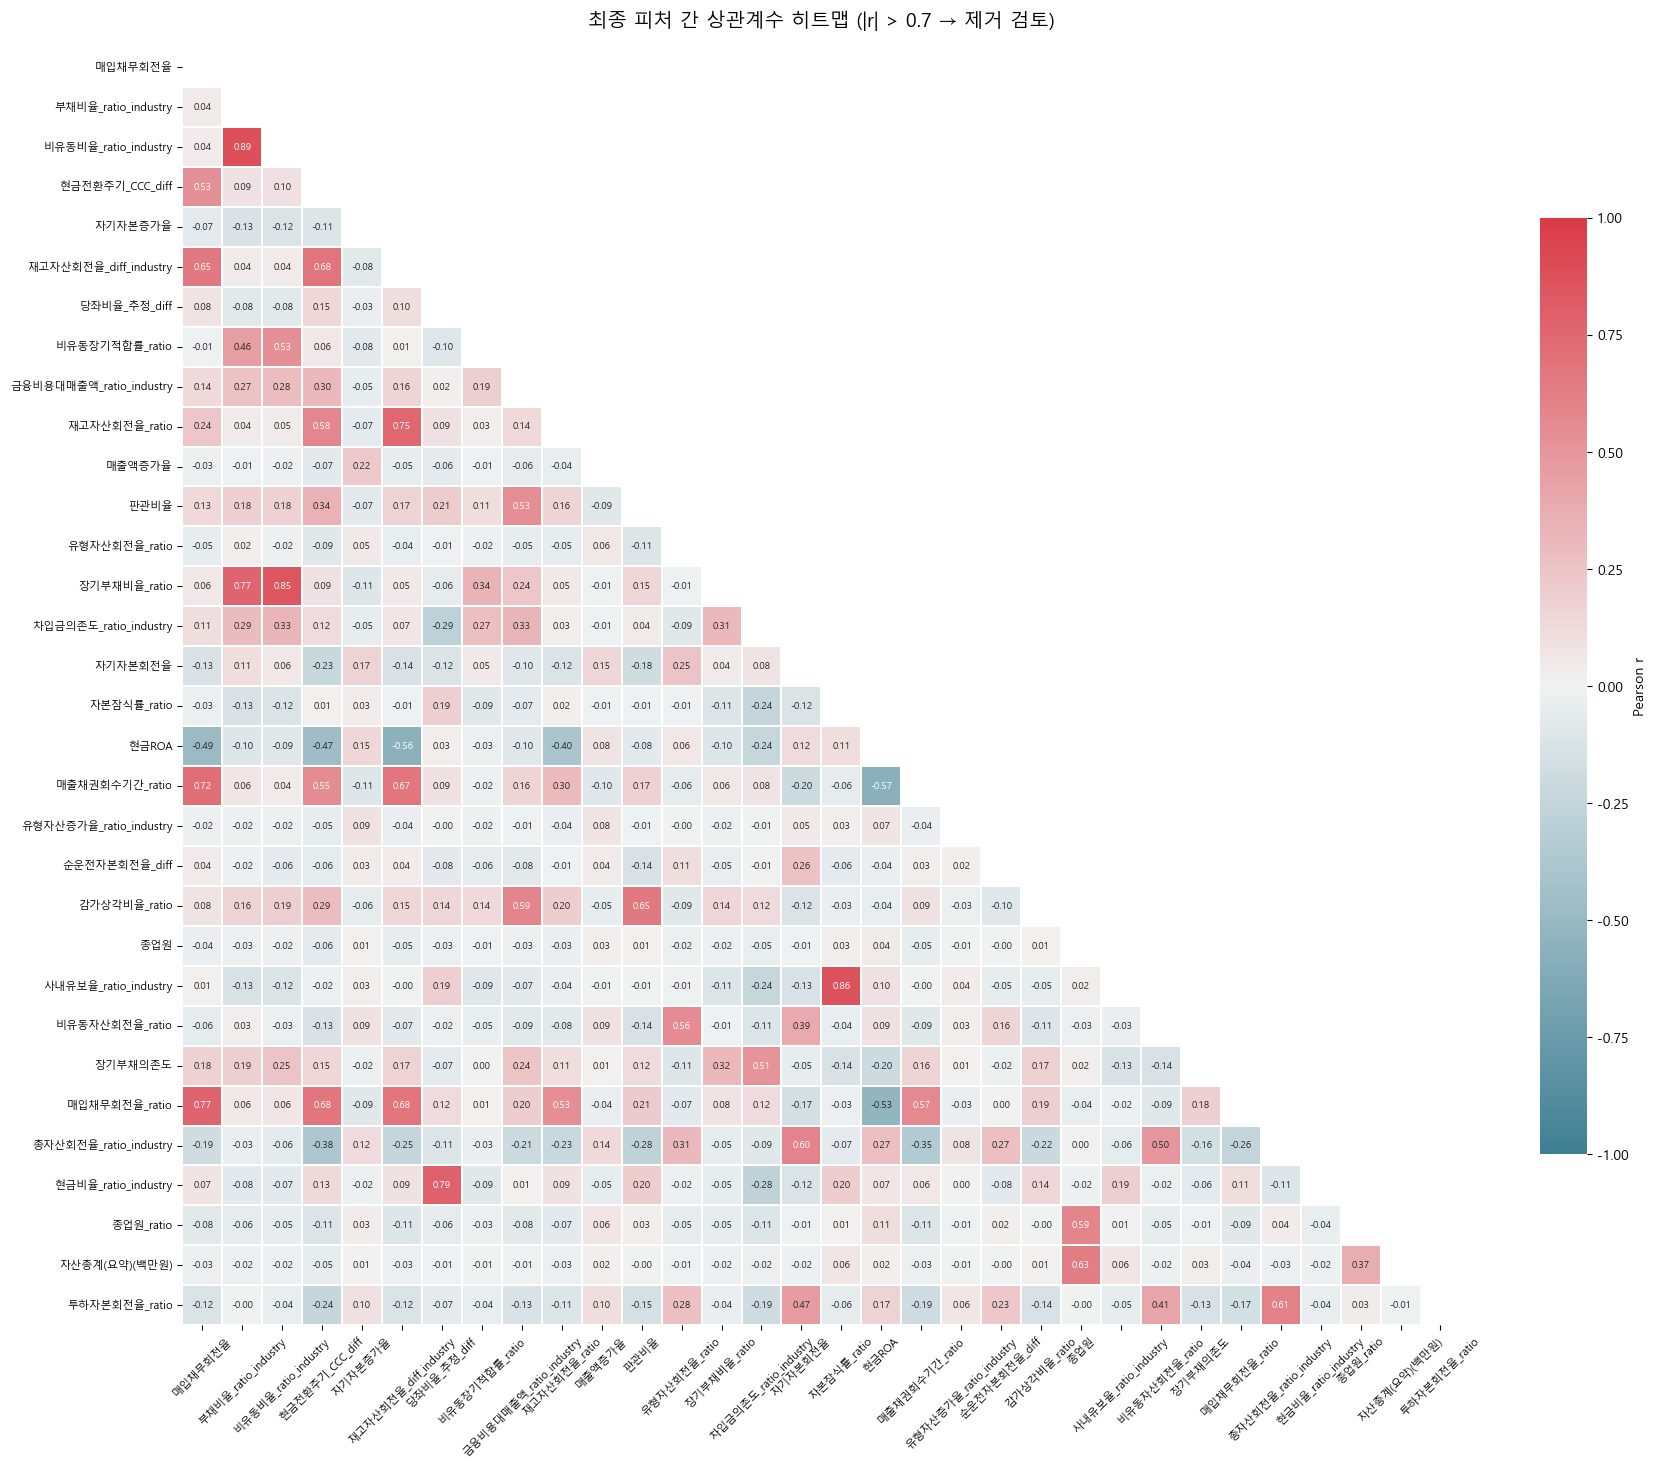

✅ 저장 완료: C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\13번.피처셀렉션\M19_도매_소매업\covariance_heatmap.png

|r| >= 0.7 인 쌍: 8개

            feature_A            feature_B  pearson_r
  부채비율_ratio_industry 비유동비율_ratio_industry     0.8879
          자본잠식률_ratio 사내유보율_ratio_industry     0.8610
 비유동비율_ratio_industry         장기부채비율_ratio     0.8487
         당좌비율_추정_diff  현금비율_ratio_industry     0.7860
              매입채무회전율        매입채무회전율_ratio     0.7714
  부채비율_ratio_industry         장기부채비율_ratio     0.7692
재고자산회전율_diff_industry        재고자산회전율_ratio     0.7466
              매입채무회전율       매출채권회수기간_ratio     0.7186

✅ 고상관 쌍 저장: high_correlation_pairs.csv


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os

# ── 설정 ─────────────────────────────────────────────────────────────────────
DATA_PATH     = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\10,11,12번\train데이터\M19_도매_소매업_train.parquet'
FEATURES_CSV  = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\13번.피처셀렉션\M19_도매_소매업\final_features.csv'
OUTPUT_DIR    = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\13번.피처셀렉션\M19_도매_소매업'
OUTPUT_IMG    = os.path.join(OUTPUT_DIR, 'covariance_heatmap.png')

# 한글 폰트 설정 (Windows 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 ───────────────────────────────────────────────────────────────
df = pd.read_parquet(DATA_PATH)

features_df = pd.read_csv(FEATURES_CSV)
FINAL = features_df['final_feature'].tolist()

X = df[FINAL].copy()
X = X.fillna(X.median())

# ── 상관계수 행렬 계산 ────────────────────────────────────────────────────────
corr_matrix = X.corr(method='pearson')

# ── 히트맵 시각화 ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 15))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    linewidths=0.3,
    linecolor='white',
    square=True,
    ax=ax,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}
)

ax.set_title('최종 피처 간 상관계수 히트맵 (|r| > 0.7 → 제거 검토)', fontsize=14, pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_IMG, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ 저장 완료: {OUTPUT_IMG}")

# ── |r| >= 0.7 고상관 쌍 출력 ────────────────────────────────────────────────
threshold = 0.7
high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= threshold:
            high_corr.append({
                'feature_A': corr_matrix.columns[i],
                'feature_B': corr_matrix.columns[j],
                'pearson_r': round(r, 4)
            })

high_corr_df = pd.DataFrame(high_corr).sort_values('pearson_r', key=abs, ascending=False)

print(f"\n|r| >= {threshold} 인 쌍: {len(high_corr_df)}개\n")
print(high_corr_df.to_string(index=False))

high_corr_df.to_csv('high_correlation_pairs.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ 고상관 쌍 저장: high_correlation_pairs.csv")

- 뺄것들

매입채무회전율_ratio
재고자산회전율_ratio
비유동비율_ratio_industry
자본잠식률_ratio
당좌비율_추정_diff
장기부채비율_ratio
매출채권회수기간_ratio

## 다시 공선성 확인

제거 전: 32개  →  제거 후: 25개


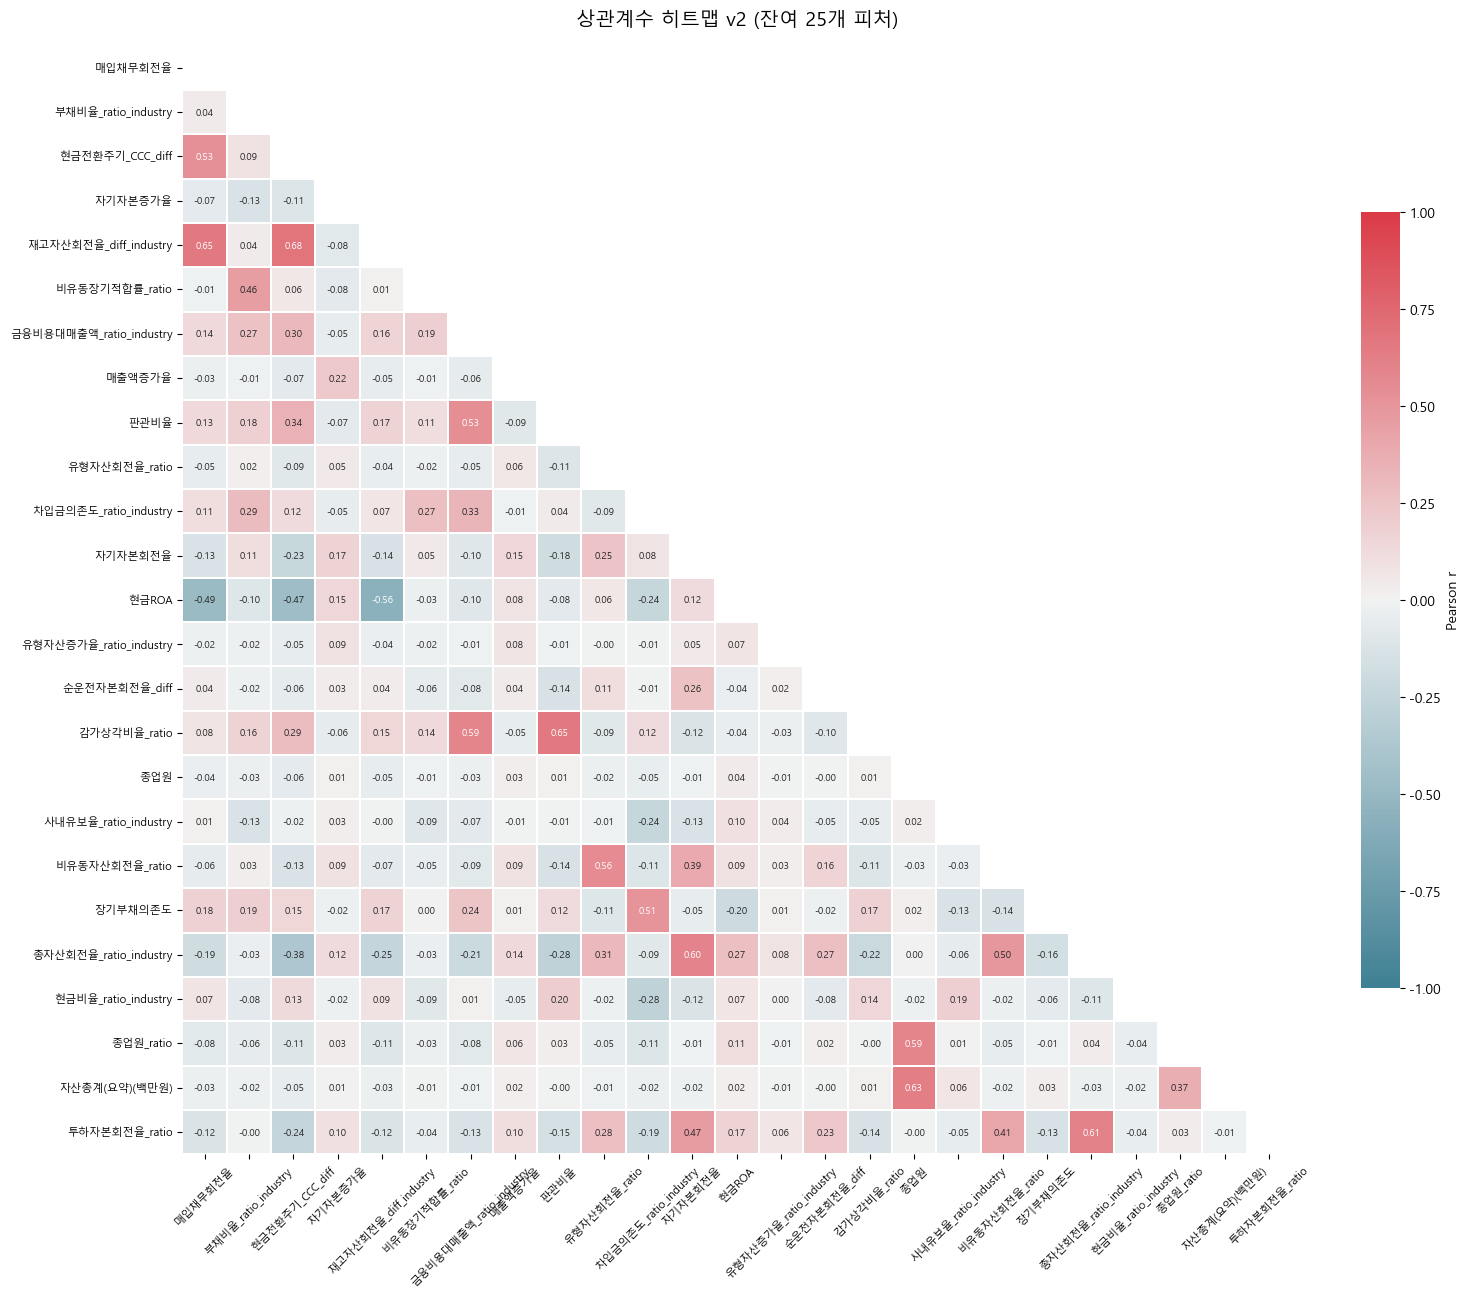

✅ 저장 완료: C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\13번.피처셀렉션\M19_도매_소매업\covariance_heatmap_한번제거후.png

|r| >= 0.5 인 쌍: 13개

              feature_A             feature_B  pearson_r
        현금전환주기_CCC_diff 재고자산회전율_diff_industry     0.6812
                매입채무회전율 재고자산회전율_diff_industry     0.6526
                   판관비율          감가상각비율_ratio     0.6510
                    종업원         자산총계(요약)(백만원)     0.6256
  총자산회전율_ratio_industry         투하자본회전율_ratio     0.6110
                자기자본회전율 총자산회전율_ratio_industry     0.5999
                    종업원             종업원_ratio     0.5928
금융비용대매출액_ratio_industry          감가상각비율_ratio     0.5899
  재고자산회전율_diff_industry                 현금ROA    -0.5636
          유형자산회전율_ratio        비유동자산회전율_ratio     0.5615
금융비용대매출액_ratio_industry                  판관비율     0.5336
                매입채무회전율       현금전환주기_CCC_diff     0.5287
  차입금의존도_ratio_industry               장기부채의존도     0.5105

✅ 최종 피처 저장: final_features_v2.csv (25개)


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── 설정 ─────────────────────────────────────────────────────────────────────
DATA_PATH    = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\10,11,12번\train데이터\M19_도매_소매업_train.parquet'
FEATURES_CSV = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\13번.피처셀렉션\M19_도매_소매업\final_features.csv'
OUTPUT_IMG   = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\13번.피처셀렉션\M19_도매_소매업\covariance_heatmap_한번제거후.png'

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 제거할 컬럼 ───────────────────────────────────────────────────────────────
DROP_COLS = [
    '매입채무회전율_ratio',
    '재고자산회전율_ratio',
    '비유동비율_ratio_industry',
    '자본잠식률_ratio',
    '당좌비율_추정_diff',
    '장기부채비율_ratio',
    '매출채권회수기간_ratio',
]

# ── 데이터 로드 ───────────────────────────────────────────────────────────────
df = pd.read_parquet(DATA_PATH)

features_df = pd.read_csv(FEATURES_CSV)
FINAL = [col for col in features_df['final_feature'].tolist() if col not in DROP_COLS]

print(f"제거 전: {len(features_df)}개  →  제거 후: {len(FINAL)}개")

X = df[FINAL].copy()
X = X.fillna(X.median())

# ── 상관계수 행렬 ─────────────────────────────────────────────────────────────
corr_matrix = X.corr(method='pearson')

# ── 히트맵 ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 13))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=sns.diverging_palette(220, 10, as_cmap=True),
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    linewidths=0.3,
    linecolor='white',
    square=True,
    ax=ax,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}
)

ax.set_title(f'상관계수 히트맵 v2 (잔여 {len(FINAL)}개 피처)', fontsize=14, pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_IMG, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ 저장 완료: {OUTPUT_IMG}")

# ── |r| >= 0.7 고상관 쌍 출력 ────────────────────────────────────────────────
threshold = 0.5
high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= threshold:
            high_corr.append({
                'feature_A': corr_matrix.columns[i],
                'feature_B': corr_matrix.columns[j],
                'pearson_r': round(r, 4)
            })

high_corr_df = pd.DataFrame(high_corr).sort_values('pearson_r', key=abs, ascending=False)

print(f"\n|r| >= {threshold} 인 쌍: {len(high_corr_df)}개\n")
if len(high_corr_df) > 0:
    print(high_corr_df.to_string(index=False))
else:
    print("고상관 쌍 없음 ✅")

high_corr_df.to_csv('high_correlation_pairs_v2.csv', index=False, encoding='utf-8-sig')

# ── 최종 피처 저장 ────────────────────────────────────────────────────────────
pd.DataFrame({'final_feature': FINAL}).to_csv('final_features_v2.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ 최종 피처 저장: final_features_v2.csv ({len(FINAL)}개)")

## 공분산 최종 제거

제거 전: 25개  →  제거 후: 14개
최종 피처 목록: ['부채비율_ratio_industry', '자기자본증가율', '재고자산회전율_diff_industry', '매출액증가율', '판관비율', '유형자산회전율_ratio', '자기자본회전율', '유형자산증가율_ratio_industry', '순운전자본회전율_diff', '사내유보율_ratio_industry', '장기부채의존도', '현금비율_ratio_industry', '자산총계(요약)(백만원)', '투하자본회전율_ratio']


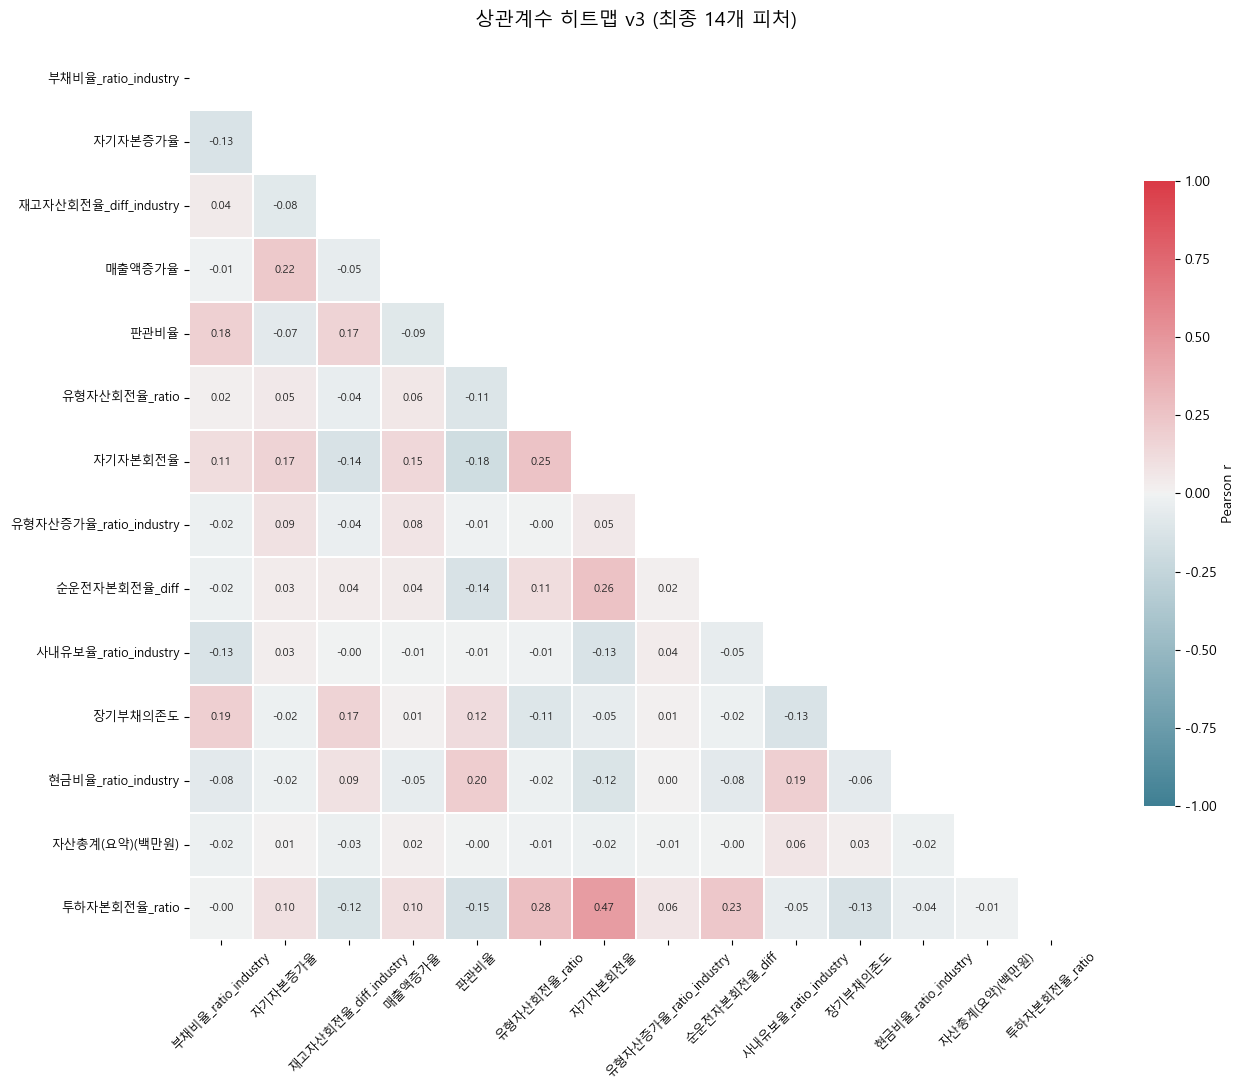

✅ 저장 완료: C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\13번.피처셀렉션\M19_도매_소매업\covariance_heatmap_최종.png

|r| >= 0.5 인 쌍 없음 ✅ 모든 피처 간 |r| < 0.7

✅ 최종 피처 저장: final_features_v3.csv (14개)


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── 설정 ─────────────────────────────────────────────────────────────────────
DATA_PATH    = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\10,11,12번\train데이터\M19_도매_소매업_train.parquet'
FEATURES_CSV = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\13번.피처셀렉션\M19_도매_소매업\final_features_공분산1차제거.csv'
OUTPUT_IMG   = r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\13번.피처셀렉션\M19_도매_소매업\covariance_heatmap_최종.png'

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 추가 제거 컬럼 ────────────────────────────────────────────────────────────
DROP_COLS = [
    '매입채무회전율',
    '현금ROA',
    '종업원',
    '금융비용대매출액_ratio_industry',
    '차입금의존도_ratio_industry',
    '총자산회전율_ratio_industry',
    '현금전환주기_CCC_diff',
    '비유동장기적합률_ratio',
    '감가상각비율_ratio',
    '종업원_ratio',
    '비유동자산회전율_ratio'
]

# ── 데이터 로드 ───────────────────────────────────────────────────────────────
df = pd.read_parquet(DATA_PATH)

features_df = pd.read_csv(FEATURES_CSV)
FINAL = [col for col in features_df['final_feature'].tolist() if col not in DROP_COLS]

print(f"제거 전: {len(features_df)}개  →  제거 후: {len(FINAL)}개")
print(f"최종 피처 목록: {FINAL}")

X = df[FINAL].copy()
X = X.fillna(X.median())

# ── 상관계수 행렬 ─────────────────────────────────────────────────────────────
corr_matrix = X.corr(method='pearson')

# ── 히트맵 ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=sns.diverging_palette(220, 10, as_cmap=True),
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    linewidths=0.3,
    linecolor='white',
    square=True,
    ax=ax,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}
)

ax.set_title(f'상관계수 히트맵 v3 (최종 {len(FINAL)}개 피처)', fontsize=14, pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_IMG, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ 저장 완료: {OUTPUT_IMG}")

# ── |r| >= 0.7 고상관 쌍 출력 ────────────────────────────────────────────────
threshold = 0.5
high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= threshold:
            high_corr.append({
                'feature_A': corr_matrix.columns[i],
                'feature_B': corr_matrix.columns[j],
                'pearson_r': round(r, 4)
            })

high_corr_df = pd.DataFrame(high_corr) if high_corr else pd.DataFrame(columns=['feature_A', 'feature_B', 'pearson_r'])

if not high_corr_df.empty:
    high_corr_df = high_corr_df.sort_values('pearson_r', key=abs, ascending=False)
    print(f"\n|r| >= {threshold} 인 쌍: {len(high_corr_df)}개\n")
    print(high_corr_df.to_string(index=False))
else:
    print(f"\n|r| >= {threshold} 인 쌍 없음 ✅ 모든 피처 간 |r| < 0.7")

# ── 최종 피처 저장 ────────────────────────────────────────────────────────────
high_corr_df.to_csv(r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\13번.피처셀렉션\M19_도매_소매업\high_correlation_pairs_최종.csv', index=False, encoding='utf-8-sig')
pd.DataFrame({'final_feature': FINAL}).to_csv('final_features_v3.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ 최종 피처 저장: final_features_v3.csv ({len(FINAL)}개)")